In [1]:
# ==============================================================================
# --- CELDA 1: IMPORTACIONES Y MÓDULOS ---
# ==============================================================================
import os
import numpy as np
import rasterio
import fiona
from datetime import datetime
import time
import gc
import shutil

# --- Adiciones para Paralelización, Monitoreo y Visualización ---
import psutil
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import geopandas as gpd
import rasterio.plot
from rasterio.windows import from_bounds
from shapely.geometry import box

# --- Importar los módulos personalizados del paquete lcp ---
import lcp.data_loader as dl
import lcp.processing as proc
import lcp.pathfinder as pf
import lcp.utils as utils
import lcp.postprocessing as postp 

print("Módulos cargados exitosamente.")

Módulos cargados exitosamente.


In [2]:
# ==============================================================================
# --- CELDA 2: DEFINICIÓN DE FUNCIONES ---
# ==============================================================================

def _calculate_n_jobs_for_phase(raster_shape, raster_dtype, phase):
    """
    Estima cuantos workers paralelos caben en la RAM disponible para cada fase.

    Fase 1 (MCP): cada worker necesita raster (float64) + costs (float64) +
                  traceback (int8).  Aprox. 2.125x el tamaño del raster en bytes.

    Fase 2 (reconstruccion): cada worker solo carga el traceback comprimido desde
                  disco (~30-80 MB) + buffer de path (~200 KB).  Usa el doble de
                  CPUs logicos para maximizar I/O.
    """
    import psutil
    import numpy as np
    import sys

    available_ram = psutil.virtual_memory().available
    raster_bytes = np.prod(raster_shape) * np.dtype(raster_dtype).itemsize

    if phase == 1:
        # MCP_Geometric internamente asigna: flat_costs (f64) + heap (f64) +
        # heap structure (i16) + offsets (i64, 2xHxW) + traceback (i8).
        # Mas la copia del raster que lee el worker (~1x).  Total real: ~5.5x raster.
        mem_per_worker = raster_bytes * 5.5
        n_jobs = max(1, int(available_ram * 0.80 / mem_per_worker))
        n_cpu = psutil.cpu_count(logical=True) or 1
        n_jobs = min(n_jobs, n_cpu)
    else:
        # Fase 2: traceback comprimido en disco -> mucho menos RAM
        # 80 MB por worker (estimado conservador para traceback descomprimido)
        mem_per_worker = 80 * 1024 * 1024
        n_jobs = max(1, int(available_ram * 0.80 / mem_per_worker))
        n_cpu = psutil.cpu_count(logical=True) or 1
        n_jobs = min(n_jobs, n_cpu * 2)

    # --- AGREGAR ESTE BLOQUE ---
    if sys.platform == "win32":
        n_jobs = min(n_jobs, 61)   # límite de WaitForMultipleObjects en Windows

    return n_jobs


def warm_up_numba():
    """
    Pre-compila reconstruct_path_from_traceback con Numba JIT usando datos de prueba.
    Debe llamarse en cada proceso worker antes del bucle principal para evitar que
    el primer origen real pague el costo de compilacion JIT.
    """
    print("Pre-compilando funcion Numba (warm-up)...")
    dummy_raster = np.ones((10, 10), dtype=np.float64)
    from skimage.graph import MCP_Geometric
    mcp = MCP_Geometric(dummy_raster, fully_connected=True)
    _, dummy_traceback = mcp.find_costs([(5, 5)])
    pf.reconstruct_path_from_traceback(dummy_traceback, (5, 5), (2, 2))
    print("Warm-up completado.")


In [3]:
# ==============================================================================
# --- CELDA 3: CONFIGURACIÓN CENTRAL DEL ANÁLISIS ---
# ==============================================================================
# --- 1. Parámetros de Rutas ---
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(R"C:\Users\LAV\Desktop\Proyecto Vannia\Proceso\coste")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = os.path.join(BASE_DIR, 'output', f'session_{timestamp}_Refactored')

COST_RASTER_PATH = os.path.join(DATA_DIR, 'Coste 2.tif')
ALL_POINTS_SHAPEFILE = os.path.join(R"C:\Users\LAV\Desktop\Proyecto Vannia\puntos poligono y sitios.gpkg")
MASK_SHAPEFILE_PATH = R"C:\Users\LAV\Desktop\Proyecto Vannia\QGIS\Poligono ampliado AE.gpkg"
ID_FIELD_NAME = 'fid'

# --- 2. Opciones de Almacenamiento ---
# Si es True, la carpeta phase1_tracebacks/ (5-13 GB) se conserva al terminar.
# Si es False (recomendado), se elimina automáticamente al finalizar la Celda 6.
KEEP_PHASE1_FILES = False

# Verbosidad del análisis: True imprime detalles por ruta, False suprime el ruido.
VERBOSE = False

# Crear el directorio de salida inmediatamente después de definir su ruta.
# Esto asegura que estará disponible para todas las celdas posteriores (5, 6, 7).
try:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Directorio de salida creado/verificado en: {OUTPUT_DIR}")
except OSError as e:
    print(f"!! ERROR CRÍTICO !! No se pudo crear el directorio de salida. Error: {e}")
    # Detener la ejecución si no se puede crear la carpeta
    raise

print("Parámetros de configuración cargados. Los resultados se guardarán en:", OUTPUT_DIR)

Directorio de salida creado/verificado en: C:\Users\LAV\Desktop\Proyecto Vannia\Least-Cost-Path\output\session_20260622_124647_Refactored
Parámetros de configuración cargados. Los resultados se guardarán en: C:\Users\LAV\Desktop\Proyecto Vannia\Least-Cost-Path\output\session_20260622_124647_Refactored


In [4]:
# ==============================================================================
# --- CELDA 4: VERIFICACIÓN DE COHERENCIA DE DATOS ---
# ==============================================================================
print("\n--- VERIFICANDO LA COHERENCIA DE TODOS LOS DATOS DE ENTRADA ---")

main_search_mask = None  # Inicializar la variable para que esté disponible globalmente en la celda

try:
    # --- Etapa 1: Comprobación de Sistemas de Coordenadas (CRS) ---
    print("--- Etapa 1: Comprobación de Sistemas de Coordenadas (CRS) ---")
    
    with rasterio.open(COST_RASTER_PATH) as src:
        raster_crs = src.crs
    
    with fiona.open(ALL_POINTS_SHAPEFILE) as src:
        points_crs = src.crs

    print(f"  > CRS del Ráster: {raster_crs.to_string()}")
    print(f"  > CRS de los Puntos: {fiona.crs.to_string(points_crs)}")

    crs_errors = []
    if raster_crs != points_crs:
        crs_errors.append("El CRS de los PUNTOS no coincide con el del RÁSTER.")
    
    mask_crs = None
    if MASK_SHAPEFILE_PATH and os.path.exists(MASK_SHAPEFILE_PATH):
        with fiona.open(MASK_SHAPEFILE_PATH) as src:
            mask_crs = src.crs
        print(f"  > CRS de la Máscara: {fiona.crs.to_string(mask_crs)}")
        if raster_crs != mask_crs:
            crs_errors.append("El CRS de la MÁSCARA no coincide con el del RÁSTER.")
    
    if not crs_errors:
        print("¡Correcto! Todos los sistemas de coordenadas coinciden.")
    
    # --- Etapa 2: Comprobación de Superposición Espacial ---
    print("\n--- Etapa 2: Comprobación de Superposición Espacial ---")
    
    with rasterio.open(COST_RASTER_PATH) as src:
        raster_bounds = src.bounds
        raster_box = box(*raster_bounds)

    points_gdf = gpd.read_file(ALL_POINTS_SHAPEFILE)
    points_bounds = points_gdf.total_bounds
    points_box = box(*points_bounds)
    
    print(f"  > Extensión del Ráster: {raster_bounds}")
    print(f"  > Extensión de los Puntos: {tuple(points_bounds)}")

    superposition_errors = []
    if not points_box.within(raster_box):
        superposition_errors.append("La extensión de los PUNTOS no está completamente contenida dentro de la extensión del RÁSTER.")

    if MASK_SHAPEFILE_PATH and os.path.exists(MASK_SHAPEFILE_PATH):
        mask_gdf = gpd.read_file(MASK_SHAPEFILE_PATH)
        if not mask_gdf.empty:
            mask_bounds = mask_gdf.total_bounds
            mask_box = box(*mask_bounds)
            print(f"  > Extensión de la Máscara: {tuple(mask_bounds)}")
            if not mask_box.intersects(raster_box):
                superposition_errors.append("La extensión de la MÁSCARA no se superpone (intersecta) con la extensión del RÁSTER.")
    
    if not superposition_errors:
        print("¡Correcto! Todas las capas se superponen geográficamente.")

    # --- Etapa 3: Creación y Validación Lógica de la Máscara y Puntos ---
    print("\n--- Etapa 3: Creación y Validación Lógica Final (Máscara + Nodata + Puntos) ---")
    
    with rasterio.open(COST_RASTER_PATH) as src:
        # 3.1: Crear la máscara a partir del polígono vectorial
        if MASK_SHAPEFILE_PATH and os.path.exists(MASK_SHAPEFILE_PATH):
            vector_mask = proc.create_mask_from_vector(MASK_SHAPEFILE_PATH, src)
        else:
            print("  ADVERTENCIA: No se proporcionó un archivo de máscara. Se usará toda la extensión del ráster.")
            vector_mask = np.ones(src.shape, dtype=bool)

        # 3.2: Crear una máscara a partir de los valores 'nodata' del ráster
        original_cost_data = src.read(1)
        nodata_value = src.nodata
        if nodata_value is not None:
            nodata_mask = (original_cost_data == nodata_value)
            print(f"  > Se han detectado {np.sum(nodata_mask)} píxeles con valor 'nodata' en el ráster.")
        else:
            nodata_mask = np.zeros(src.shape, dtype=bool)
        
        # 3.3: Combinar ambas para obtener la máscara de búsqueda final y definitiva
        main_search_mask = vector_mask & ~nodata_mask
        
        # 3.4: Cargar los puntos y validarlos contra la MÁSCARA FINAL
        all_points_for_validation, _ = dl.load_points_as_dict(ALL_POINTS_SHAPEFILE, ID_FIELD_NAME)
        invalid_point_ids = []
        for point_id, coords in all_points_for_validation.items():
            row, col = rasterio.transform.rowcol(src.transform, coords[0], coords[1])
            if not (0 <= row < src.height and 0 <= col < src.width) or not main_search_mask[row, col]:
                invalid_point_ids.append(str(point_id))

        if not invalid_point_ids:
            print("¡Correcto! Todos los puntos están dentro del área de búsqueda válida final.")
    
    # --- Etapa 4: Veredicto Final ---
    final_errors = crs_errors + superposition_errors
    
    if invalid_point_ids:
        error_message_points = (
            f"Se encontraron {len(invalid_point_ids)} puntos que caen sobre píxeles INVÁLIDOS. "
            f"Un píxel es inválido si está fuera del polígono de la máscara O si tiene un valor 'nodata' en el ráster de coste. "
            f"(IDs de muestra: {', '.join(invalid_point_ids[:10])}{'...' if len(invalid_point_ids) > 10 else ''})."
        )
        final_errors.append(error_message_points)

    if final_errors:
        error_details = "\n- ".join(final_errors)
        error_message = (
            f"\n{'='*70}\n"
            f"!! ERROR CRÍTICO DE VALIDACIÓN DE DATOS !!\n"
            f"Se encontraron las siguientes inconsistencias:\n- {error_details}\n\n"
            f"El análisis no puede continuar. Debes corregir tus datos de entrada. Comprueba la posición de los puntos inválidos respecto a las áreas 'nodata' en tu software GIS.\n"
            f"{'='*70}"
        )
        raise ValueError(error_message)
    else:
        print("\n¡Excelente! Todos los datos de entrada son coherentes y están listos para el análisis.")

except Exception as e:
    print(f"Ocurrió un error inesperado durante la validación de datos: {e}")
    raise


--- VERIFICANDO LA COHERENCIA DE TODOS LOS DATOS DE ENTRADA ---
--- Etapa 1: Comprobación de Sistemas de Coordenadas (CRS) ---
  > CRS del Ráster: EPSG:32719
  > CRS de los Puntos: EPSG:32719
  > CRS de la Máscara: EPSG:32719
¡Correcto! Todos los sistemas de coordenadas coinciden.

--- Etapa 2: Comprobación de Superposición Espacial ---
  > Extensión del Ráster: BoundingBox(left=289612.6383, bottom=6091340.0489, right=573022.6383, top=6253160.0489)
  > Extensión de los Puntos: (np.float64(289678.20507429476), np.float64(6091403.900487711), np.float64(572924.8995482503), np.float64(6253106.021557365))
  > Extensión de la Máscara: (np.float64(289612.63832153566), np.float64(6091344.907505719), np.float64(573021.819113796), np.float64(6253160.0489291195))
¡Correcto! Todas las capas se superponen geográficamente.

--- Etapa 3: Creación y Validación Lógica Final (Máscara + Nodata + Puntos) ---
Creando máscara booleana desde el polígono (con limpieza de geometría)...
Máscara creada exitosam


Iniciando visualización diagnóstica del ráster de coste y puntos...

Visualización diagnóstica guardada en: C:\Users\LAV\Desktop\Proyecto Vannia\Least-Cost-Path\output\session_20260622_124647_Refactored\visualizacion_diagnostica.png


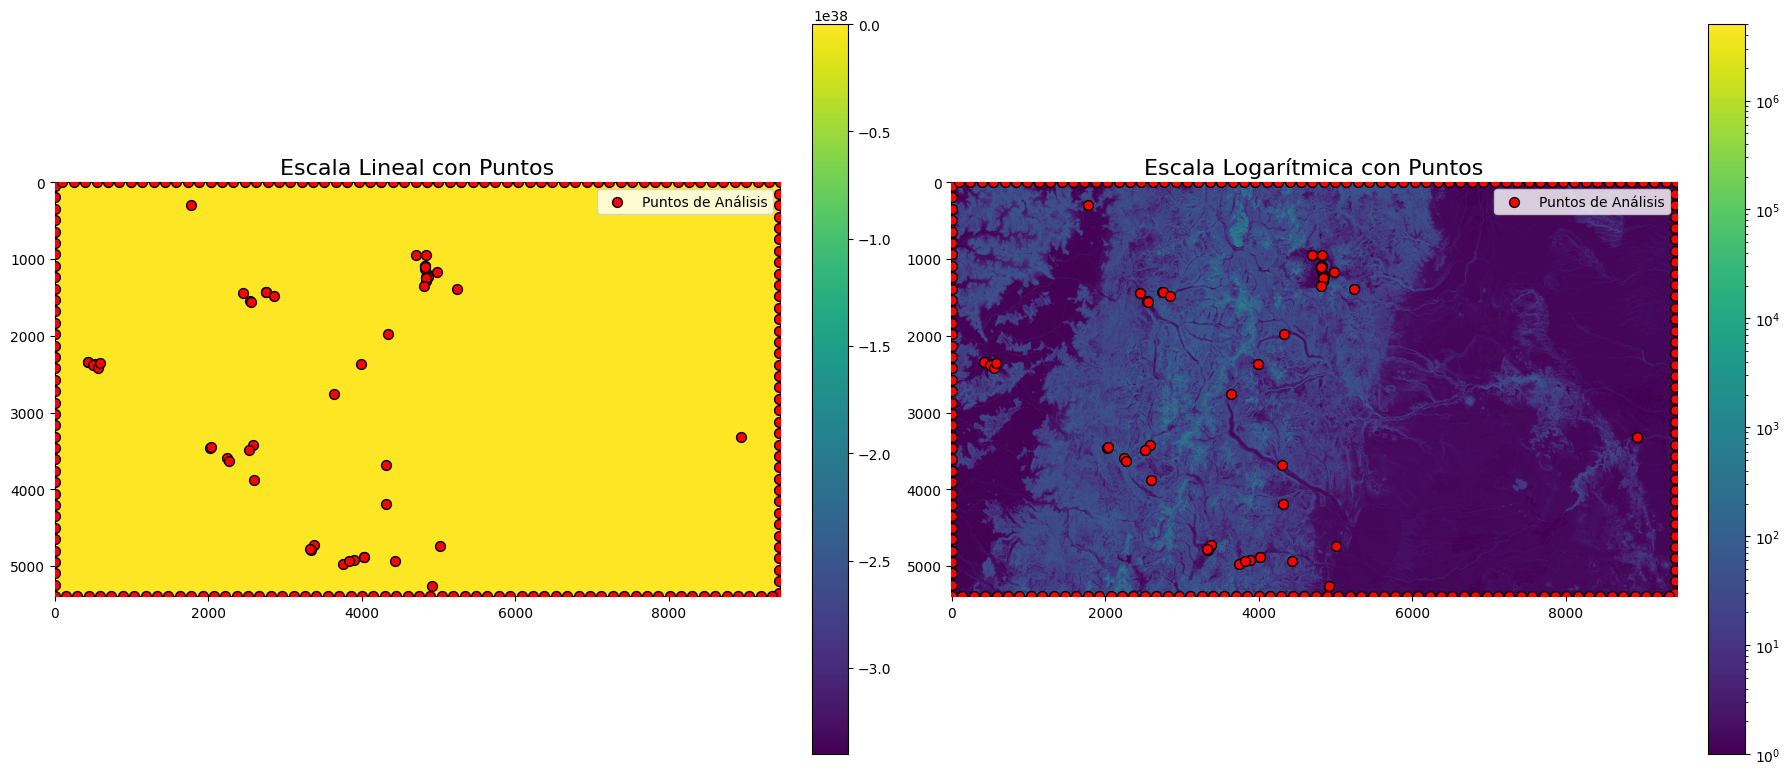

In [5]:
# ==============================================================================
# --- CELDA 5: VISUALIZACIÓN DIAGNÓSTICA (CON EXPORTACIÓN) ---
# ==============================================================================
print("\nIniciando visualización diagnóstica del ráster de coste y puntos...")
try:
    # Cargar el ráster de coste para obtener sus datos y metadatos
    with rasterio.open(COST_RASTER_PATH) as src:
        cost_data = src.read(1)
        transform = src.transform  # Guardar la transformación para convertir coordenadas

        # Preparar datos para la escala logarítmica, manejando valores no positivos
        min_pos_val = np.min(cost_data[cost_data > 0]) if np.any(cost_data > 0) else 1e-9
        cost_data_log = np.where(cost_data <= 0, min_pos_val, cost_data)

        # Cargar los puntos usando geopandas
        points_gdf = gpd.read_file(ALL_POINTS_SHAPEFILE)
        
        # Convertir las coordenadas geográficas de los puntos a coordenadas de píxel
        point_pixels_x = []
        point_pixels_y = []
        for point in points_gdf.geometry:
            # Usar rasterio.transform.rowcol para obtener fila y columna
            row, col = rasterio.transform.rowcol(transform, point.x, point.y)
            point_pixels_x.append(col)
            point_pixels_y.append(row)

        # Crear la figura y los ejes para los dos subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))

        # --- Subplot 1: Visualización con Escala Lineal ---
        im1 = ax1.imshow(cost_data, cmap='viridis')
        fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
        ax1.set_title('Escala Lineal con Puntos', fontsize=16)
        ax1.scatter(point_pixels_x, point_pixels_y, c='red', edgecolor='black', s=50, label='Puntos de Análisis', zorder=5)
        ax1.legend()

        # --- Subplot 2: Visualización con Escala Logarítmica ---
        im2 = ax2.imshow(cost_data_log, cmap='viridis', norm=LogNorm())
        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
        ax2.set_title('Escala Logarítmica con Puntos', fontsize=16)
        ax2.scatter(point_pixels_x, point_pixels_y, c='red', edgecolor='black', s=50, label='Puntos de Análisis', zorder=5)
        ax2.legend()

        # Ajustes finales
        plt.tight_layout()

        # --- INICIO DE LA MODIFICACIÓN: EXPORTACIÓN DE LA IMAGEN ---
        # Guardar la figura en el directorio de salida antes de mostrarla
        output_image_path = os.path.join(OUTPUT_DIR, 'visualizacion_diagnostica.png')
        # Usamos dpi=150 para una buena resolución y bbox_inches='tight' para eliminar bordes blancos
        fig.savefig(output_image_path, dpi=150, bbox_inches='tight')
        print(f"\nVisualización diagnóstica guardada en: {output_image_path}")
        # --- FIN DE LA MODIFICACIÓN ---

        # Mostrar el gráfico en la pantalla
        plt.show()

except FileNotFoundError as e:
    print(f"ADVERTENCIA: No se encontró un archivo necesario para la visualización: {e}. Saltando visualización.")
except Exception as e:
    print(f"Ocurrió un error durante la visualización: {e}")
    import traceback
    traceback.print_exc()

In [6]:
# ==============================================================================
# --- CELDA 6: EJECUCIÓN EN DOS FASES (FASE 1: MCP + FASE 2: RECONSTRUCCIÓN) ---
# ==============================================================================
#
# FASE 1 — Dijkstra / MCP_Geometric por origen:
#   Cada worker calcula la superficie de coste completa desde su origen,
#   extrae los costes escalares para cada destino y guarda el traceback
#   comprimido (int8, ~30-80 MB) en OUTPUT_DIR/phase1_tracebacks/.
#
# FASE 2 — Reconstrucción de rutas:
#   Cada worker carga el traceback de un origen desde disco y reconstruye
#   todas las rutas hacia destinos > origin_id.
#
# Al finalizar, si KEEP_PHASE1_FILES es False, se elimina phase1_tracebacks/.
# ==============================================================================
print("\n--- INICIANDO PROCESO DE ANÁLISIS EN DOS FASES ---\n")
os.makedirs(OUTPUT_DIR, exist_ok=True)

PHASE1_DIR = os.path.join(OUTPUT_DIR, "phase1_tracebacks")
os.makedirs(PHASE1_DIR, exist_ok=True)

memmap_path = os.path.join(OUTPUT_DIR, "_raster_shared.dat")
all_route_records = []

try:
    # ------------------------------------------------------------------
    # PASO 1 — Preparar datos y escribir raster en memmap compartido
    # ------------------------------------------------------------------
    print("[Paso 1/5] Preparando datos en memoria...")
    all_points, points_crs = dl.load_points_as_dict(ALL_POINTS_SHAPEFILE, ID_FIELD_NAME)

    with dl.load_raster(COST_RASTER_PATH) as src:
        transform = src.transform
        raster_crs = src.crs
        original_cost_data = src.read(1)
        final_cost_raster = np.where(main_search_mask, original_cost_data, np.inf).astype(np.float64)
        raster_shape = final_cost_raster.shape
        raster_dtype = final_cost_raster.dtype
        del original_cost_data

    print(f"  Forma raster: {raster_shape}, dtype: {raster_dtype}")

    print("[Paso 2/5] Escribiendo raster en memmap compartido...")
    mm = np.memmap(memmap_path, dtype=raster_dtype, mode="w+", shape=raster_shape)
    mm[:] = final_cost_raster[:]
    mm.flush()
    del mm, final_cost_raster
    print(f"  Memmap escrito en: {memmap_path}")

    shared_data = {
        "memmap_path":  memmap_path,
        "raster_dtype": raster_dtype,
        "raster_shape": raster_shape,
        "src_transform": transform,
    }

    # Warm-up Numba en proceso principal (compila la función JIT una vez)
    warm_up_numba()

    # Pre-calcular píxeles de destino para no repetir la conversión en cada worker
    dest_pixels_all = {
        pid: proc.world_to_pixel(transform, coords[0], coords[1])
        for pid, coords in all_points.items()
    }

    # ------------------------------------------------------------------
    # PASO 3 — FASE 1: MCP por origen → traceback_N.npz + costes escalares
    # ------------------------------------------------------------------
    n_jobs_p1 = _calculate_n_jobs_for_phase(raster_shape, raster_dtype, phase=1)
    print(f"\n[Paso 3/5] FASE 1 — MCP en paralelo ({n_jobs_p1} workers)...")

    tasks_p1 = []
    for origin_id, origin_coords in all_points.items():
        origin_pixel = proc.world_to_pixel(transform, origin_coords[0], origin_coords[1])
        dest_pixels = {
            did: dest_pixels_all[did]
            for did in all_points
            if did > origin_id
        }
        tasks_p1.append((origin_id, origin_pixel, dest_pixels, shared_data, PHASE1_DIR))

    print(f"  Total de orígenes a procesar: {len(tasks_p1)}")
    t0_p1 = time.time()

    results_p1 = Parallel(n_jobs=n_jobs_p1, backend="loky", verbose=5)(
        delayed(pf.compute_and_save_cost_surface)(args) for args in tasks_p1
    )

    dur_p1 = time.time() - t0_p1
    print(f"\n[Paso 3/5] Fase 1 completada en {dur_p1:.1f} s.")

    # Construir índice de costes escalares: {origin_id: {dest_id: float}}
    cost_scalars_index = {oid: cdict for oid, cdict in results_p1}
    n_computed = sum(1 for cdict in cost_scalars_index.values() if cdict)
    print(f"  Tracebacks guardados: {n_computed}/{len(tasks_p1)}")

    # ------------------------------------------------------------------
    # PASO 4 — FASE 2: Reconstrucción de rutas desde disco
    # ------------------------------------------------------------------
    n_jobs_p2 = _calculate_n_jobs_for_phase(raster_shape, raster_dtype, phase=2)
    print(f"\n[Paso 4/5] FASE 2 — Reconstrucción en paralelo ({n_jobs_p2} workers)...")

    tasks_p2 = []
    for origin_id, origin_coords in all_points.items():
        cost_scalars = cost_scalars_index.get(origin_id, {})
        if not cost_scalars:
            # Sin traceback guardado para este origen; omitir.
            continue
        dest_items = [
            (did, all_points[did])
            for did in cost_scalars
        ]
        tasks_p2.append((origin_id, origin_coords, dest_items, cost_scalars, transform, PHASE1_DIR))

    print(f"  Total de orígenes para reconstrucción: {len(tasks_p2)}")
    t0_p2 = time.time()

    results_p2 = Parallel(n_jobs=n_jobs_p2, backend="loky", verbose=5)(
        delayed(postp.reconstruct_routes_from_disk)(args) for args in tasks_p2
    )

    dur_p2 = time.time() - t0_p2
    for origin_id, records in results_p2:
        all_route_records.extend(records)

    print(f"\n[Paso 4/5] Fase 2 completada en {dur_p2:.1f} s.")
    print(f"  Rutas reconstruidas: {len(all_route_records)}")

    # ------------------------------------------------------------------
    # PASO 5 — Escribir GeoPackage unificado
    # ------------------------------------------------------------------
    print("\n[Paso 5/5] Escribiendo GeoPackage unificado...")
    routes_gdf = gpd.GeoDataFrame(all_route_records, crs=raster_crs)
    gpkg_output_path = os.path.join(OUTPUT_DIR, "red_completa_unificada.gpkg")
    routes_gdf.to_file(gpkg_output_path, driver="GPKG", layer="rutas_unificadas")
    print(f"[Paso 5/5] {len(routes_gdf)} rutas guardadas en: {gpkg_output_path}")

    # Limpiar archivos temporales
    if os.path.exists(memmap_path):
        os.remove(memmap_path)
        print(f"  Memmap temporal eliminado.")

    if not KEEP_PHASE1_FILES:
        shutil.rmtree(PHASE1_DIR, ignore_errors=True)
        print(f"  Tracebacks de Fase 1 eliminados (KEEP_PHASE1_FILES=False).")
    else:
        print(f"  Tracebacks de Fase 1 conservados en: {PHASE1_DIR}")

    total_duration = dur_p1 + dur_p2
    print("\n" + "="*60)
    print("--- RESUMEN DE EJECUCIÓN (DOS FASES) ---")
    print(f"  Fase 1 (MCP, {len(tasks_p1)} orígenes):    {dur_p1:.1f} s  ({n_jobs_p1} workers)")
    print(f"  Fase 2 (rutas, {len(tasks_p2)} orígenes):  {dur_p2:.1f} s  ({n_jobs_p2} workers)")
    print(f"  Total:                         {total_duration:.1f} s")
    print(f"  Rutas generadas:               {len(routes_gdf)}")
    print("="*60)

except Exception as e:
    print(f"\nERROR CRÍTICO en Celda 6: {e}")
    import traceback as tb
    tb.print_exc()



--- INICIANDO PROCESO DE ANÁLISIS EN DOS FASES ---

[Paso 1/5] Preparando datos en memoria...
Cargando puntos desde: puntos poligono y sitios.gpkg
  ADVERTENCIA: Campo 'fid' no encontrado en propiedades. Se usará el 'feature.id' (fid del GeoPackage).
Se cargaron 251 puntos.
Cargando raster desde: Coste 2.tif
  Forma raster: (5394, 9447), dtype: float64
[Paso 2/5] Escribiendo raster en memmap compartido...
  Memmap escrito en: C:\Users\LAV\Desktop\Proyecto Vannia\Least-Cost-Path\output\session_20260622_124647_Refactored\_raster_shared.dat
Pre-compilando funcion Numba (warm-up)...
Warm-up completado.

[Paso 3/5] FASE 1 — MCP en paralelo (32 workers)...
  Total de orígenes a procesar: 251


[Parallel(n_jobs=32)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done   8 tasks      | elapsed:  1.8min
[Parallel(n_jobs=32)]: Done  98 tasks      | elapsed:  6.5min
[Parallel(n_jobs=32)]: Done 239 out of 251 | elapsed: 12.7min remaining:   38.1s
[Parallel(n_jobs=32)]: Done 251 out of 251 | elapsed: 12.9min finished
[Parallel(n_jobs=61)]: Using backend LokyBackend with 61 concurrent workers.



[Paso 3/5] Fase 1 completada en 772.2 s.
  Tracebacks guardados: 250/251

[Paso 4/5] FASE 2 — Reconstrucción en paralelo (61 workers)...
  Total de orígenes para reconstrucción: 250


[Parallel(n_jobs=61)]: Done  40 tasks      | elapsed:   46.8s
[Parallel(n_jobs=61)]: Done 180 out of 250 | elapsed:  1.3min remaining:   30.9s
[Parallel(n_jobs=61)]: Done 231 out of 250 | elapsed:  1.3min remaining:    6.5s
[Parallel(n_jobs=61)]: Done 250 out of 250 | elapsed:  1.4min finished



[Paso 4/5] Fase 2 completada en 81.6 s.
  Rutas reconstruidas: 31374

[Paso 5/5] Escribiendo GeoPackage unificado...
[Paso 5/5] 31374 rutas guardadas en: C:\Users\LAV\Desktop\Proyecto Vannia\Least-Cost-Path\output\session_20260622_124647_Refactored\red_completa_unificada.gpkg
  Memmap temporal eliminado.
  Tracebacks de Fase 1 eliminados (KEEP_PHASE1_FILES=False).

--- RESUMEN DE EJECUCIÓN (DOS FASES) ---
  Fase 1 (MCP, 251 orígenes):    772.2 s  (32 workers)
  Fase 2 (rutas, 250 orígenes):  81.6 s  (61 workers)
  Total:                         853.8 s
  Rutas generadas:               31374



Iniciando la visualización final de la red de rutas...
Visualizando 31374 rutas.

Visualización final guardada en: C:\Users\LAV\Desktop\Proyecto Vannia\Least-Cost-Path\output\session_20260622_124647_Refactored\red_de_rutas_final.png


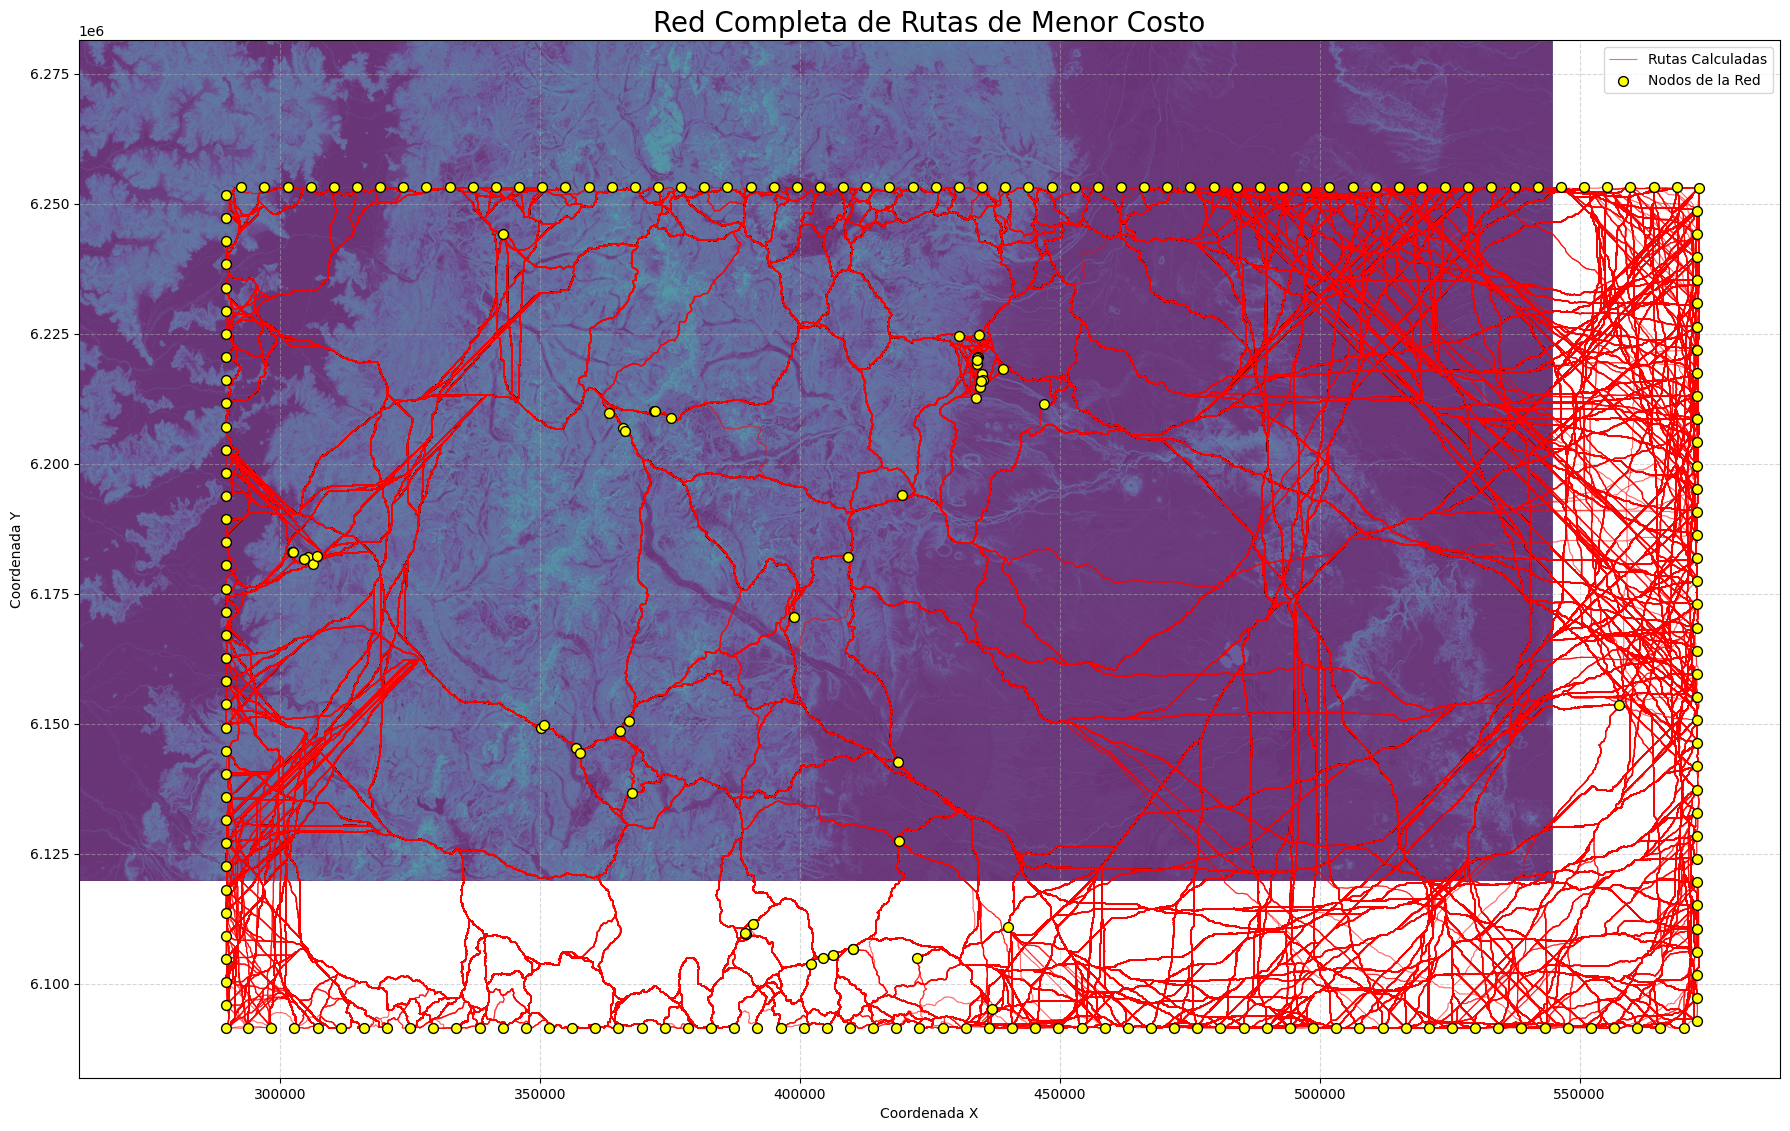

In [7]:
# ==============================================================================
# --- CELDA 7: VISUALIZACIÓN Y EXPORTACIÓN FINAL DE RESULTADOS ---
# ==============================================================================
print("\nIniciando la visualización final de la red de rutas...")

try:
    # Usar el GeoDataFrame construido en memoria por la Celda 6.
    # Si por alguna razón no existe (e.g. se ejecuta esta celda de forma aislada),
    # se carga desde el GeoPackage guardado.
    if 'routes_gdf' not in dir() or routes_gdf is None or len(routes_gdf) == 0:
        print("routes_gdf no disponible en memoria; cargando desde el GeoPackage...")
        routes_gdf = gpd.read_file(
            os.path.join(OUTPUT_DIR, 'red_completa_unificada.gpkg'),
            layer='rutas_unificadas'
        )

    final_routes_gdf = routes_gdf

    if len(final_routes_gdf) == 0:
        print("No hay rutas para visualizar.")
    else:
        print(f"Visualizando {len(final_routes_gdf)} rutas.")

        # 0. Obtener CRS del raster
        with rasterio.open(COST_RASTER_PATH) as src:
            raster_crs = src.crs

        # 1. Armonizar CRS — reprojectar rutas y puntos al CRS del raster si difieren
        if final_routes_gdf.crs is None:
            print("  ADVERTENCIA: routes_gdf sin CRS; asignando raster CRS.")
            final_routes_gdf = final_routes_gdf.set_crs(raster_crs)
        elif final_routes_gdf.crs != raster_crs:
            print(f"  Reproyectando rutas de {final_routes_gdf.crs} → {raster_crs}")
            final_routes_gdf = final_routes_gdf.to_crs(raster_crs)

        points_gdf = gpd.read_file(ALL_POINTS_SHAPEFILE)
        if points_gdf.crs is None:
            print("  ADVERTENCIA: points_gdf sin CRS; asignando raster CRS.")
            points_gdf = points_gdf.set_crs(raster_crs)
        elif points_gdf.crs != raster_crs:
            print(f"  Reproyectando puntos de {points_gdf.crs} → {raster_crs}")
            points_gdf = points_gdf.to_crs(raster_crs)

        # 2. Extensión geográfica total (en raster CRS)
        minx, miny, maxx, maxy = final_routes_gdf.total_bounds
        margin = (maxx - minx) * 0.1
        buffered_bounds = (minx - margin, miny - margin, maxx + margin, maxy + margin)

        # 3. Cargar la porción del ráster de coste
        with rasterio.open(COST_RASTER_PATH) as src:
            import math
            window = from_bounds(*buffered_bounds, transform=src.transform)
            # Alinear ventana a píxeles enteros (read redondea, transform no)
            col_off = int(math.floor(window.col_off))
            row_off = int(math.floor(window.row_off))
            col_stop = int(math.ceil(window.col_off + window.width))
            row_stop = int(math.ceil(window.row_off + window.height))
            window = rasterio.windows.Window(col_off, row_off, col_stop - col_off, row_stop - row_off)
            raster_data = src.read(1, window=window)
            window_transform = src.window_transform(window)

        # 4. Crear el mapa
        fig, ax = plt.subplots(figsize=(18, 18))

        min_pos_val = np.min(raster_data[raster_data > 0]) if np.any(raster_data > 0) else 1e-9
        raster_data_log = np.where(raster_data <= 0, min_pos_val, raster_data)

        from rasterio.plot import plotting_extent
        extent = plotting_extent(raster_data_log, window_transform)
        ax.imshow(raster_data_log, extent=extent, origin='upper',
                  cmap='viridis', norm=LogNorm(), alpha=0.8)

        final_routes_gdf.plot(ax=ax, edgecolor='red', linewidth=0.8,
                              label='Rutas Calculadas', alpha=0.6, zorder=3)
        points_gdf.plot(ax=ax, color='yellow', markersize=50, ec='black',
                        label='Nodos de la Red', zorder=5)

        # 5. Configuración final del mapa
        ax.set_title('Red Completa de Rutas de Menor Costo', fontsize=20)
        ax.set_xlabel("Coordenada X"); ax.set_ylabel("Coordenada Y")
        ax.legend(); plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()

        output_image_path = os.path.join(OUTPUT_DIR, 'red_de_rutas_final.png')
        fig.savefig(output_image_path, dpi=300, bbox_inches='tight')
        print(f"\nVisualización final guardada en: {output_image_path}")

        plt.show()
except Exception as e:
    print(f"Ocurrió un error durante la visualización: {e}")
    import traceback as tb
    tb.print_exc()


In [8]:
# ==============================================================================
# --- CELDA 8: PUNTOS DENSIFICADOS (FIONA DIRECTO, SIN SHAPELY POINTS) ---
# ==============================================================================
import os, time, gc
import numpy as np
import shapely
from shapely import get_coordinates
from joblib import Parallel, delayed
import fiona

SPACING_M = 25.0
CHUNK_SIZE = 500
N_WORKERS = 18

t0 = time.time()
print(f"\n{'='*60}")
print(f"  CELDA 8: PUNTOS CADA {SPACING_M} m — FIONA DIRECTO")
print(f"{'='*60}")

# ── 1. AUTO-DETECTAR RUTAS ──
def _find_latest_gpkg(root):
    out = os.path.join(root, 'output')
    if not os.path.isdir(out): return None, None
    sessions = sorted(
        [d for d in os.listdir(out) if d.startswith('session_')],
        key=lambda s: os.path.getmtime(os.path.join(out, s)), reverse=True
    )
    for s in sessions:
        d = os.path.join(out, s)
        gpkg = os.path.join(d, 'red_completa_unificada.gpkg')
        if os.path.exists(gpkg): return gpkg, d
    return None, None

if 'routes_gdf' in dir() and routes_gdf is not None and len(routes_gdf) > 0:
    pass
elif 'OUTPUT_DIR' in dir() and os.path.exists(p := os.path.join(OUTPUT_DIR, 'red_completa_unificada.gpkg')):
    routes_gdf = gpd.read_file(p, layer='rutas_unificadas')
else:
    import geopandas as gpd
    gpkg, sess_dir = _find_latest_gpkg(os.getcwd())
    if gpkg is None:
        raise FileNotFoundError("red_completa_unificada.gpkg no encontrado")
    OUTPUT_DIR = sess_dir
    routes_gdf = gpd.read_file(gpkg, layer='rutas_unificadas')
    print(f"  Última sesión: {os.path.basename(sess_dir)}")

n_routes = len(routes_gdf)
print(f"  [1/5] Rutas: {n_routes:,}")

# ── 2. PRE-CÓMPUTO ──
lengths = shapely.length(routes_gdf.geometry.values)
n_pts_arr = np.ceil(lengths / SPACING_M).astype(np.int32) + 1
total_pts = int(n_pts_arr.sum())
print(f"  [2/5] Longitud: {lengths.sum()/1000:,.0f} km | Puntos: {total_pts:,}")

# ── 3. COORDENADAS + CHUNKS ──
print(f"  [3/5] Extrayendo coordenadas...")
coords_list = [get_coordinates(g) for g in routes_gdf.geometry.values]
_crs_rutas = routes_gdf.crs
del routes_gdf; gc.collect()

chunks = [
    (np.arange(i, min(i+CHUNK_SIZE, n_routes), dtype=np.int32),
     coords_list[i:i+CHUNK_SIZE], lengths[i:i+CHUNK_SIZE],
     n_pts_arr[i:i+CHUNK_SIZE], float(SPACING_M))
    for i in range(0, n_routes, CHUNK_SIZE)
]
del coords_list, lengths, n_pts_arr; gc.collect()
print(f"        {len(chunks)} lotes × {N_WORKERS} workers")

# ── 4. WORKER (puro numpy, sin GEOS) ──
def densify_chunk(indices, coords_list, lengths, n_pts_arr, spacing):
    chunk_x, chunk_y, chunk_idx = [], [], []
    for idx, coords, length, n in zip(indices, coords_list, lengths, n_pts_arr):
        n = int(n)
        dists = np.linspace(0, float(length), n)
        seg_vecs = np.diff(coords, axis=0)
        seg_lens = np.sqrt((seg_vecs ** 2).sum(axis=1))
        cum_len = np.concatenate([[0], seg_lens.cumsum()])
        cum_norm = cum_len / float(cum_len[-1])
        i = np.searchsorted(cum_norm, dists / float(length), side='right') - 1
        i = np.clip(i, 0, len(coords) - 2)
        t = (dists - cum_len[i]) / (seg_lens[i] + 1e-30)
        chunk_x.append(coords[i, 0] + t * seg_vecs[i, 0])
        chunk_y.append(coords[i, 1] + t * seg_vecs[i, 1])
        chunk_idx.append(np.full(n, idx, dtype=np.int32))
    return (np.concatenate(chunk_x), np.concatenate(chunk_y),
            np.concatenate(chunk_idx))

# ── 5. EJECUTAR ──
t1 = time.time()
print(f"  [4/5] Interpolando {len(chunks)} lotes...")
results = Parallel(n_jobs=N_WORKERS, verbose=10, prefer="processes")(
    delayed(densify_chunk)(*c) for c in chunks
)
del chunks; gc.collect()
t2 = time.time()

# ── 6. CONCATENAR ──
print(f"  [5/5] Concatenando y escribiendo GPKG directo...")
xs = np.concatenate([r[0] for r in results])
ys = np.concatenate([r[1] for r in results])
all_idx = np.concatenate([r[2] for r in results])
del results; gc.collect()
n_total = len(xs)

# ── 7. GPKG DIRECTO CON FIONA (sin make_points, sin GeoDataFrame) ──
output_path = os.path.join(OUTPUT_DIR, f'puntos_rutas_{int(SPACING_M)}m.gpkg')
schema = {'geometry': 'Point', 'properties': {'route_idx': 'int'}}
crs_wkt = str(_crs_rutas)

BATCH = 200_000
with fiona.open(output_path, 'w', driver='GPKG', schema=schema, crs=crs_wkt) as dst:
    for start in range(0, n_total, BATCH):
        end = min(start + BATCH, n_total)
        features = [
            {'geometry': {'type': 'Point', 'coordinates': (float(xs[j]), float(ys[j]))},
             'properties': {'route_idx': int(all_idx[j])}}
            for j in range(start, end)
        ]
        dst.writerecords(features)
        print(f"    Escritos {end:,} / {n_total:,} ({end*100//n_total}%)", end='\r')

del xs, ys, all_idx; gc.collect()
t3 = time.time()

gpkg_mb = os.path.getsize(output_path) / 1e6
print(f"\n\n{'─'*60}")
print(f"  {n_total:,} puntos | {gpkg_mb:.0f} MB")
print(f"  {output_path}")
print(f"  Interpolación: {t2-t1:.1f} s | GPKG: {t3-t2:.1f} s | TOTAL: {t3-t0:.1f} s")
print(f"{'─'*60}")


  CELDA 8: PUNTOS CADA 25.0 m — FIONA DIRECTO
  [1/5] Rutas: 31,374
  [2/5] Longitud: 6,665,777 km | Puntos: 266,678,186
  [3/5] Extrayendo coordenadas...
        63 lotes × 18 workers
  [4/5] Interpolando 63 lotes...


[Parallel(n_jobs=18)]: Using backend LokyBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done   5 tasks      | elapsed:    1.9s
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    4.4s
[Parallel(n_jobs=18)]: Done  25 tasks      | elapsed:    7.0s
[Parallel(n_jobs=18)]: Done  35 out of  63 | elapsed:    9.2s remaining:    7.3s
[Parallel(n_jobs=18)]: Done  42 out of  63 | elapsed:   10.9s remaining:    5.4s
[Parallel(n_jobs=18)]: Done  49 out of  63 | elapsed:   12.3s remaining:    3.4s
[Parallel(n_jobs=18)]: Done  56 out of  63 | elapsed:   13.4s remaining:    1.6s
[Parallel(n_jobs=18)]: Done  63 out of  63 | elapsed:   14.3s finished


  [5/5] Concatenando y escribiendo GPKG directo...
    Escritos 266,678,186 / 266,678,186 (100%)

────────────────────────────────────────────────────────────
  266,678,186 puntos | 27518 MB
  C:\Users\LAV\Desktop\Proyecto Vannia\Least-Cost-Path\output\session_20260622_124647_Refactored\puntos_rutas_25m.gpkg
  Interpolación: 18.3 s | GPKG: 7294.9 s | TOTAL: 7315.6 s
────────────────────────────────────────────────────────────



Generando mapa de calor (QGIS-style)...
  Resolución: 30 m/px
  Bandwidth:  10.0 km
  Kernel:     quartic
  Grid: 10109 × 6058 celdas (61.2 Mpx)
  Pixel real: 29.9990 × 29.9983 m
  Rasterizando puntos via numpy binning...
  Kernel size: 669 × 669 px
  Aplicando kernel via FFT...
  GeoTIFF: C:\Users\LAV\Desktop\Proyecto Vannia\Least-Cost-Path\output\session_20260622_124647_Refactored\heatmap_30m_10km_quartic.tif
  PNG:     C:\Users\LAV\Desktop\Proyecto Vannia\Least-Cost-Path\output\session_20260622_124647_Refactored\heatmap_30m_10km_quartic.png


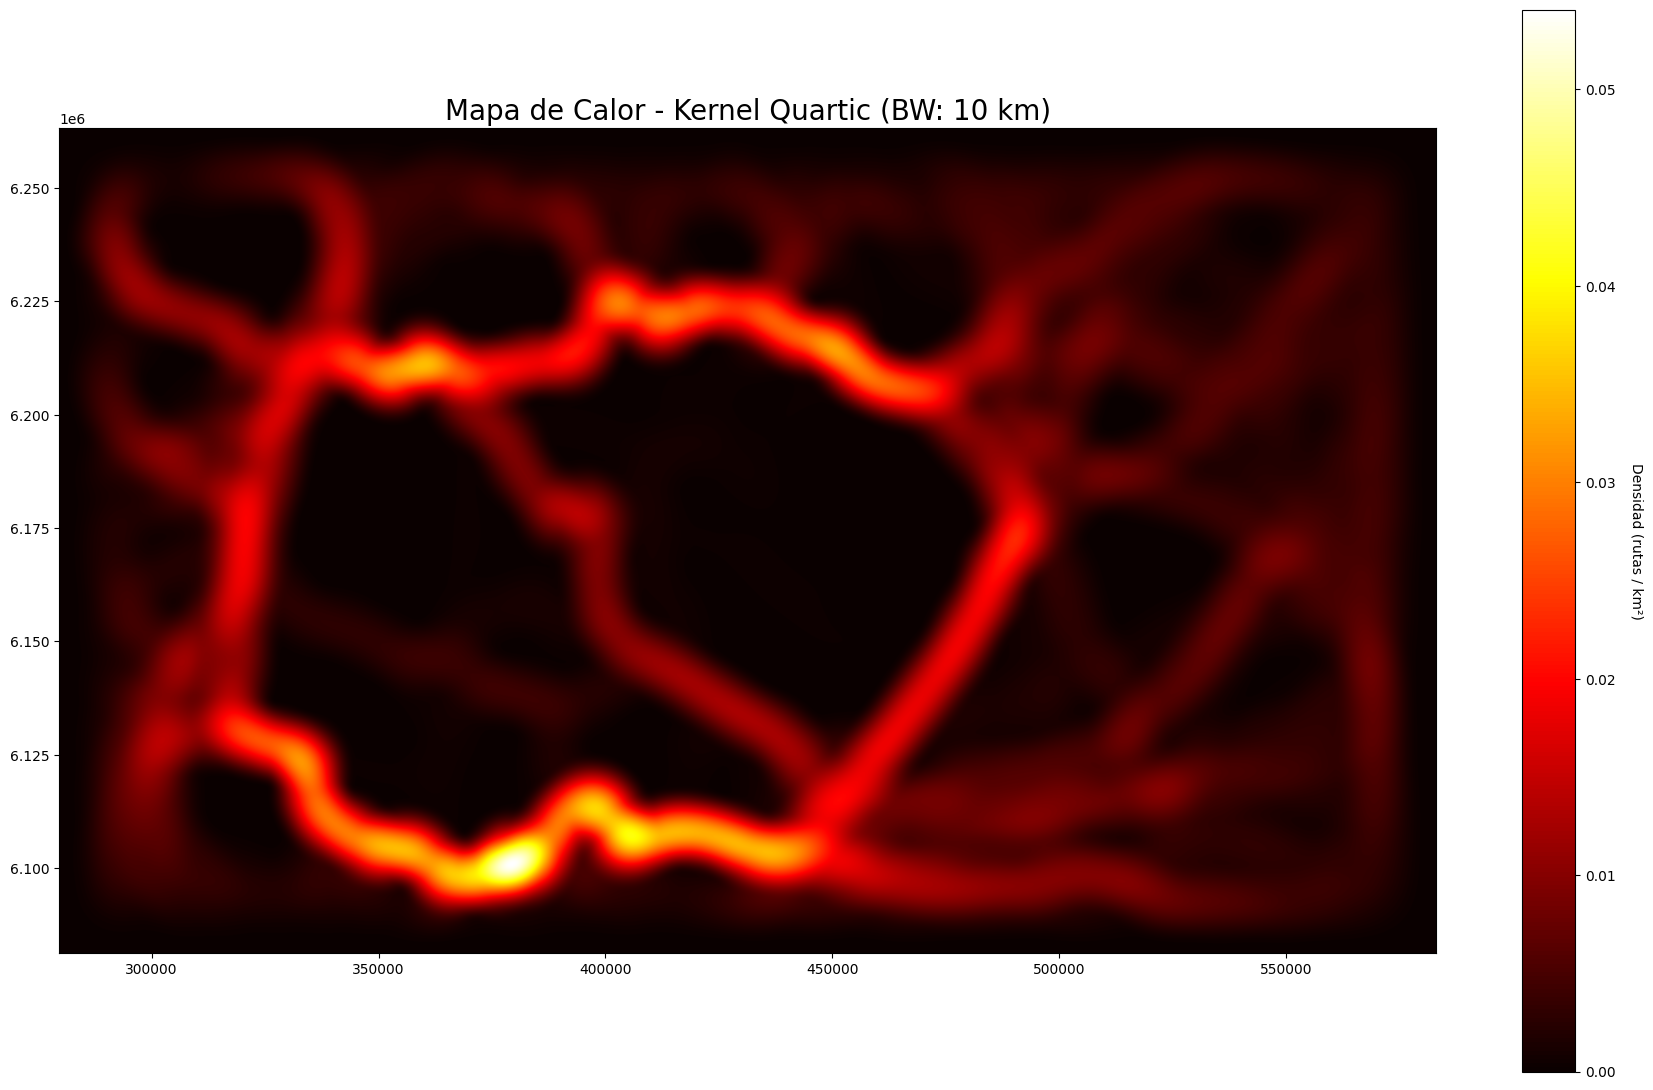

In [9]:
# ==============================================================================
# --- CELDA 9: MAPA DE CALOR ESTILO QGIS (KERNEL QUARTIC / BIWEIGHT) ---
# ==============================================================================
import os
import numpy as np
import rasterio
from rasterio.transform import from_bounds
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.fft import rfft2, irfft2
from shapely import get_coordinates

# Parámetros configurables
HEATMAP_RES_M = 30          # Resolución espacial del raster (m/px)
HEATMAP_BANDWIDTH_M = 10000 # Radio de búsqueda / bandwidth (metros)
HEATMAP_KERNEL = "quartic"  # Kernel de QGIS: "quartic", "gaussian", "triangular", "uniform"

print(f"\nGenerando mapa de calor (QGIS-style)...")
print(f"  Resolución: {HEATMAP_RES_M} m/px")
print(f"  Bandwidth:  {HEATMAP_BANDWIDTH_M / 1000:.1f} km")
print(f"  Kernel:     {HEATMAP_KERNEL}")

if 'OUTPUT_DIR' not in dir() or not os.path.exists(os.path.join(OUTPUT_DIR, 'puntos_rutas_25m.gpkg')):
    def _find_latest(out):
        if not os.path.isdir(out): return None
        sessions = sorted([d for d in os.listdir(out) if d.startswith('session_')],
                         key=lambda s: os.path.getmtime(os.path.join(out, s)), reverse=True)
        for s in sessions:
            d = os.path.join(out, s)
            if os.path.exists(os.path.join(d, 'red_completa_unificada.gpkg')): return d
        return None
    sess_dir = _find_latest(os.path.join(os.getcwd(), 'output'))
    if sess_dir is None:
        raise FileNotFoundError('No se encontro sesion con red_completa_unificada.gpkg')
    OUTPUT_DIR = sess_dir
    print(f'  OUTPUT_DIR auto-detectado: {os.path.basename(OUTPUT_DIR)}')

points_path = os.path.join(OUTPUT_DIR, 'puntos_rutas_25m.gpkg')
points_gdf = gpd.read_file(points_path)

# --- 1. Extensión con margen = bandwidth (evita efectos de borde) ---
minx, miny, maxx, maxy = points_gdf.total_bounds
margin = HEATMAP_BANDWIDTH_M
minx -= margin; miny -= margin; maxx += margin; maxy += margin

width  = int(np.ceil((maxx - minx) / HEATMAP_RES_M))
height = int(np.ceil((maxy - miny) / HEATMAP_RES_M))
# from_bounds con paso exacto: truncamos el bounding box a multiplos exactos de HEATMAP_RES_M
# para que el tamano del pixel en el raster coincida exactamente con el paso del binning
pixel_size_x = (maxx - minx) / width
pixel_size_y = (maxy - miny) / height
transform = from_bounds(minx, miny, maxx, maxy, width, height)

print(f"  Grid: {width} × {height} celdas ({width*height/1e6:.1f} Mpx)")
print(f"  Pixel real: {pixel_size_x:.4f} × {pixel_size_y:.4f} m")

# --- 2. Numpy binning vectorizado (reemplaza rasterio.rasterize) ---
# Usar el mismo pixel_size que from_bounds para que grid de datos y raster coincidan
print("  Rasterizando puntos via numpy binning...")
coords = get_coordinates(points_gdf.geometry)
cols = ((coords[:, 0] - minx) / pixel_size_x).astype(np.int32)
rows = ((maxy - coords[:, 1]) / pixel_size_y).astype(np.int32)
valid = (cols >= 0) & (cols < width) & (rows >= 0) & (rows < height)

count_grid = np.zeros((height, width), dtype=np.float64)
np.add.at(count_grid, (rows[valid], cols[valid]), 1)

# --- 3. Construir kernel de QGIS (usando pixel_size real) ---
ps = (pixel_size_x + pixel_size_y) / 2.0
radius_px = int(np.ceil(HEATMAP_BANDWIDTH_M / ps))
y, x = np.ogrid[-radius_px:radius_px+1, -radius_px:radius_px+1]
dist_px = np.sqrt(x**2 + y**2)
u = (dist_px * ps) / HEATMAP_BANDWIDTH_M

if HEATMAP_KERNEL == "quartic":
    kernel = np.where(u <= 1, (15.0 / 16.0) * (1 - u**2)**2, 0.0)
elif HEATMAP_KERNEL == "gaussian":
    kernel = np.exp(-0.5 * u**2)
elif HEATMAP_KERNEL == "triangular":
    kernel = np.where(u <= 1, 1 - u, 0.0)
elif HEATMAP_KERNEL == "uniform":
    kernel = np.where(u <= 1, 1.0, 0.0)
else:
    raise ValueError(f"Kernel no soportado: {HEATMAP_KERNEL}")

kernel_area = np.sum(kernel) * (ps ** 2)
kernel = kernel / kernel_area

print(f"  Kernel size: {kernel.shape[0]} × {kernel.shape[1]} px")

# --- 4. Convolución via FFT (scipy.fft con MKL backend) ---
print("  Aplicando kernel via FFT...")
count_padded = np.pad(count_grid, pad_width=radius_px, mode='constant')
kernel_padded = np.zeros_like(count_padded)
kh, kw = kernel.shape
kernel_padded[:kh, :kw] = kernel

fft_grid = rfft2(count_padded)
fft_kernel = rfft2(kernel_padded)
fft_result = fft_grid * fft_kernel
heatmap = irfft2(fft_result, s=count_padded.shape)

heatmap = heatmap[2*radius_px:2*radius_px+height, 2*radius_px:2*radius_px+width]

# --- 5. Guardar GeoTIFF ---
heatmap_tif = os.path.join(OUTPUT_DIR, f'heatmap_{HEATMAP_RES_M}m_{int(HEATMAP_BANDWIDTH_M/1000)}km_{HEATMAP_KERNEL}.tif')
with rasterio.open(
    heatmap_tif,
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=1,
    dtype=heatmap.dtype,
    crs=points_gdf.crs,
    transform=transform,
    compress='lzw'
) as dst:
    dst.write(heatmap, 1)
    dst.update_tags(
        kernel=HEATMAP_KERNEL,
        bandwidth_m=HEATMAP_BANDWIDTH_M,
        resolution_m=HEATMAP_RES_M,
        method="QGIS-style KDE via FFT"
    )

print(f"  GeoTIFF: {heatmap_tif}")

# --- 6. Visualizar ---
fig, ax = plt.subplots(figsize=(18, 18))
extent = [minx, maxx, miny, maxy]
im = ax.imshow(heatmap, extent=extent, origin='upper', cmap='hot')
ax.set_title(f'Mapa de Calor - Kernel {HEATMAP_KERNEL.capitalize()} (BW: {HEATMAP_BANDWIDTH_M/1000:.0f} km)', fontsize=20)
cbar = plt.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label('Densidad (rutas / km²)', rotation=270, labelpad=20)

plt.tight_layout()
heatmap_png = os.path.join(OUTPUT_DIR, f'heatmap_{HEATMAP_RES_M}m_{int(HEATMAP_BANDWIDTH_M/1000)}km_{HEATMAP_KERNEL}.png')
fig.savefig(heatmap_png, dpi=300, bbox_inches='tight')
print(f"  PNG:     {heatmap_png}")
plt.show()
